In [1]:
##install required packages
%pip install requests
%pip install requests beautifulsoup4
%pip install selenium
%pip install --upgrade openai
%pip install mplfinance

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


# Extract News
In this part, I will scrape one year’s worth of news from The Star, i3Investor, Yahoo Finance, and Free Malaysia Today, store them separately in different CSV files, and then merge them into a single file named NewsData.csv. Since each website has a different structure, I need to write separate code for each of them.

In [2]:
import os

BASE_DIR = "Source"
RAW_NEWS_DIR = os.path.join(BASE_DIR, "Data", "raw", "news")
PROCESSED_BASE = os.path.join(BASE_DIR, "Data", "processed", "news")

os.makedirs(RAW_NEWS_DIR, exist_ok=True)
os.makedirs(PROCESSED_BASE, exist_ok=True)

In [3]:
def get_last_date_from_csv(filename):
    if not os.path.exists(filename):
        return None
    df = pd.read_csv(filename)
    if df.empty:
        return None
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    return df["Date"].max().date()

def append_and_save(df_new, csv_file):
    if df_new is None or df_new.empty:
        print(f"No new data for {csv_file}")
        return
    if os.path.exists(csv_file):
        old = pd.read_csv(csv_file)
        old["Date"] = pd.to_datetime(old["Date"], errors="coerce")
        df_new["Date"] = pd.to_datetime(df_new["Date"], errors="coerce")
        df_all = pd.concat([old, df_new], ignore_index=True)
        df_all = df_all.drop_duplicates(subset=["Date", "News"])
        df_all = df_all.sort_values("Date")
        df_all.to_csv(csv_file, index=False)
    else:
        df_new.to_csv(csv_file, index=False)


In [4]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException

def theStar():
    driver = webdriver.Chrome(options=options)
    url = "https://www.thestar.com.my/search?query=maybank"
    driver.get(url)
    
    csv_file = os.path.join(RAW_NEWS_DIR, "TheStarNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        time_constraint = datetime.today().date() - timedelta(days=730)
    else:
        time_constraint = last_date

    data = []
    urlList = []

    stop = False

    while True:
        # 等当前页的结果出来
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.ID, "resultdata"))
        )
        soup = BeautifulSoup(driver.page_source, "html.parser")

        nextPage = soup.find("div", {"id": "resultdata"})
        items = nextPage.find_all("div", class_="queryly_item_container")

        for item in items:
            date = item.find("span", class_="timestamp")
            if not date:
                continue

            date_text = date.get_text(strip=True).replace("[", "").replace("]", "")
            date_text = date_text.split("|")[0].strip()

            try:
                date_obj = pd.to_datetime(date_text, dayfirst=True, errors="coerce").date()
            except:
                continue

            # 一旦遇到旧新闻 → 整个分页都不用再翻了
            if date_obj <= time_constraint:
                stop = True
                break

            title_tag = item.find("h2", class_="f18")

            if title_tag and title_tag.find("a"):
                link = title_tag.find("a")["href"]
                data.append({
                    "Date": date_obj,
                    "URL": link,
                    "News": ""
                })

        if stop:
            break

        # ======= 点 Next Page =======
        try:
            first_link = WebDriverWait(driver, 10).until(
                EC.presence_of_element_located(
                    (By.CSS_SELECTOR, "#resultdata .queryly_item_container h2 a")
                )
            ).get_attribute("href")
            next_btn = WebDriverWait(driver, 5).until(
                EC.element_to_be_clickable((By.CSS_SELECTOR, "a.next_btn"))
            )
            driver.execute_script("arguments[0].click();", next_btn)
            WebDriverWait(driver, 10).until(
                lambda d: d.find_element(
                    By.CSS_SELECTOR,
                    "#resultdata .queryly_item_container h2 a"
                ).get_attribute("href") != first_link
            )
        except TimeoutException:
            print("No more next page or page did not change")
            break

    driver.quit()

    df_theStar = pd.DataFrame(data)
    
    driver = webdriver.Chrome(options=options)
    for idx, row in df_theStar.iterrows():
        url = row["URL"]
        try:
            driver.get(url)
            WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.TAG_NAME, "body"))
            )
            soup = BeautifulSoup(driver.page_source, "html.parser")
            locked = soup.find("div", {"id": "divDefault", "class": "card"})
            if locked and locked.find("img") and "lock" in locked.find("img")["src"]:
                print(f"Skipping locked news: {url}")
                continue
            article = soup.find("div", {"id": "story-body"})
            if article is None:
                continue
            news = article.find_all("p")
            news_content = []
            for content in news:
                if content.find("img"):
                    continue
                if content.get("class") and "caption" in content.get("class"):
                    continue
                text = content.get_text(strip=True)
                if not text:
                    continue
                news_content.append(text)
            full_text = " ".join(news_content)
            df_theStar.at[idx, "News"] = full_text
        except Exception as e:
            print("Fail:", url, e)
    driver.quit()

    save_path = os.path.join(RAW_NEWS_DIR, "TheStarNews.csv")
    append_and_save(df_theStar, save_path)

    print("The Star:")
    print(df_theStar)

def i3Investor():
    driver = webdriver.Chrome(options=options)
    url = "https://klse.i3investor.com/web/stock/news-blogs/1155"
    driver.get(url)
    time.sleep(3)

    soup = BeautifulSoup(driver.page_source, "html.parser")
    nextPage = soup.find("div", id="news-blog", class_="row m-0")
    nextPage2 = nextPage.find_all("div", class_="row m-0 mb-2")

    urlList = []
    for links in nextPage2:
        link = links.find("a", href=True)
        url1 = "https://klse.i3investor.com/" + link["href"]
        urlList.append(url1)

    csv_file = os.path.join(RAW_NEWS_DIR, "I3InvestorNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        time_constraint = datetime.today().date() - timedelta(days=730)
    else:
        time_constraint = last_date

    data = []

    for urls in urlList:
        driver.get(urls)
        time.sleep(1.5)

        soup = BeautifulSoup(driver.page_source, "html.parser")
        blog = soup.find("div", class_="row m-0 mt-1 px-1 pb-3 card disc-div")
        if blog is None:
            continue
        date = blog.find("h6", class_="subtitle small")
        if date is None:
            continue
        date_text = date.get_text(strip=True)
        parts = date_text.split(",")
        if len(parts) >= 3:
            date_text = parts[1].strip()
        date_obj = pd.to_datetime(date_text, dayfirst=True, errors="coerce")
        if pd.isna(date_obj):
            continue
        date_obj = date_obj.date()
        # 👉 只抓新数据
        if date_obj <= time_constraint:
            break
            
        article = blog.find("div", class_="px-md-3 pt-2")
        if article is None:
            continue
        news = article.find_all(["p", "h3"])
        news_content = []
        for content in news:
            if content.find("img"):
                continue
            if content.get("class") and "caption" in content.get("class"):
                continue
            text = content.get_text(strip=True)
            if not text:
                continue
            news_content.append(text)
        full_text = " ".join(news_content)
        data.append({
            "Date": date_obj,
            "News": full_text
        })
    driver.quit()

    df_i3investor = pd.DataFrame(data)
    save_path = os.path.join(RAW_NEWS_DIR, "I3InvestorNews.csv")
    append_and_save(df_i3investor, save_path)

    print("I3 Investor:")
    print(df_i3investor)

def yahooFinance():
    # Start WebDriver
    driver = webdriver.Chrome(options=options)
    # Open the dynamic page
    url = "https://finance.yahoo.com/quote/1155.KL/news/"
    driver.set_page_load_timeout(60)
    try:
        driver.get(url)
        WebDriverWait(driver, 30).until(
            EC.presence_of_element_located((By.TAG_NAME, "body"))
        )
    except TimeoutException:
        print("Yahoo Finance page timeout, skip.")
        driver.quit()
        return
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)
    # Get fully rendered HTML
    html = driver.page_source
    # Close browser
    driver.quit()

    # Parse with BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    nextPage = soup.find("section", class_="mainContent")
    nextPage2 = nextPage.find_all("li", class_="stream-item story-item yf-9xydx9")
    urlList = []
    for links in nextPage2:
        link = links.find("a", href=True)
        urlList.append(link["href"])
    
    data = []
    
    driver = webdriver.Chrome(options=options)
    for urls in urlList:
        driver.get(urls)
        time.sleep(2)
        contentHTML = driver.page_source
        # Likely to be 200 (success)
        # print(response.status_code) 
        soup = BeautifulSoup(contentHTML, "html.parser")
        date = soup.find("time", class_="byline-attr-meta-time")
        date_text = date.get_text(strip=True)
        # String to Date
        try:
            date_obj = pd.to_datetime(date_text, dayfirst=True, errors="coerce").date()
        except:
            continue
        article = soup.find("div", class_="bodyItems-wrapper")
        if article is None:
            continue
        news = article.find_all("p") 
        #re.compile(pattern) use to find out the content who have similar class name
        news_text = " ".join([content.text.strip() for content in news])
        # check whether get successfull
        data.append({"Date": date_obj, "News": news_text})
    driver.quit()
            
    df_yahooFinance = pd.DataFrame(data)
    
    csv_file = os.path.join(RAW_NEWS_DIR, "YahooFinanceNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        # 第一次
        time_constraint = datetime.today().date() - timedelta(days=730) # 2 year
    else:
        # 以后只抓新的
        time_constraint = last_date
        
    # 过滤掉超过time constraint的新闻
    df_yahooFinance = df_yahooFinance[(df_yahooFinance["Date"] > time_constraint)]
    save_path = os.path.join(RAW_NEWS_DIR, "YahooFinanceNews.csv")
    append_and_save(df_yahooFinance, save_path)
    print("Yahoo Finance:")
    print(df_yahooFinance)

def freeMalaysiaToday():
    # Start WebDriver
    driver = webdriver.Chrome(options=options)
    # Open the dynamic page
    url = "https://www.freemalaysiatoday.com/search?term=maybank&category=all"
    driver.get(url)
    time.sleep(5)

    csv_file = os.path.join(RAW_NEWS_DIR, "FreeMalaysiaTodayNews.csv")
    last_date = get_last_date_from_csv(csv_file)
    if last_date is None:
        # 第一次
        time_constraint = datetime.today().date() - timedelta(days=730) # 2 year
    else:
        # 以后只抓新的
        time_constraint = last_date
    
    while True:
        soup = BeautifulSoup(driver.page_source, "html.parser")
        cards = soup.find_all("div", class_="relative grid w-full items-center gap-4")
        if not cards:
            break
        dates = []
        for item in cards:
            time_tag = item.find("time")
            if not time_tag:
                continue
            date_str = time_tag.get("datetime") or time_tag.get_text(strip=True)
            d = pd.to_datetime(date_str, errors="coerce")
            if not pd.isna(d):
                dates.append(d.date())
        # 没有日期，不能判断，直接停
        if not dates:
            break
        oldest = min(dates)
        # 👉 已经加载到够旧了
        if oldest <= time_constraint:
            break
        # 👉 还不够旧，继续点 View More
        try:
            view_more_btn = driver.find_element(
                By.XPATH, "//button[.//text()[contains(., 'View More')]]"
            )
            driver.execute_script("arguments[0].click();", view_more_btn)
            time.sleep(4)
        except:
            # 没有 View More 按钮了
            break

    # Let JavaScript render (you may adjust the sleep time)
    time.sleep(5)
    # Get fully rendered HTML
    html = driver.page_source
    # Close browser
    driver.quit()
    # Parse with BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    nextPage = soup.find("section", class_="mt-4 flex flex-col gap-4")
    links = nextPage.find_all("div", class_="relative grid w-full items-center gap-4")
        
    # store all of the links into an array named urlList
    urlList = []
    data = []
    for item in links:
        # 抓取日期
        time_tag = item.find("time")
        if not time_tag or not time_tag.has_attr("datetime"):
            continue
        date_str = time_tag.get("datetime") or time_tag.get_text(strip=True)
        if not date_str:
            continue
        # 判断 ISO 或普通文本
        try:
            if "T" in date_str:  # ISO 格式
                date_obj = pd.to_datetime(date_str, errors="coerce").date()
            else:  # 文本日期
                date_obj = pd.to_datetime(date_str, dayfirst=True, errors="coerce").date()
        except:
            continue
        if date_obj <= time_constraint:
            continue
        # 抓取标题
        title_tag = item.find("div", class_="flex flex-col justify-around h-full")
        if title_tag and title_tag.find("a"):
            link = title_tag.find("a")["href"]
            url2 = "https://www.freemalaysiatoday.com" + link
            data.append({"Date": date_obj, "News": ""})
            urlList.append(url2)
            
    df_freeMalaysiaToday = pd.DataFrame(data)
    
    for idx, urls in enumerate(urlList):
        response = requests.get(urls)
        soup = BeautifulSoup(response.content, "html.parser")
        article = soup.find("article", class_="news-content")
        if article is None:
            continue
        news = article.find_all(["p", "div"], class_=re.compile("text-lg"))
        news_text = " ".join([content.text.strip() for content in news])
        df_freeMalaysiaToday.loc[idx, "News"] = news_text

    save_path = os.path.join(RAW_NEWS_DIR, "FreeMalaysiaTodayNews.csv")
    append_and_save(df_freeMalaysiaToday, save_path)
    print("Free Malaysia Today:")
    print(df_freeMalaysiaToday)

In [5]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
import pandas as pd
import time
import requests
import re
import os

# Set up Chrome options
options = Options()
options.add_argument("--headless")  # Run in background
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64)")

RAW_NEWS_DIR = "Source/Data/raw/news" 
os.makedirs(RAW_NEWS_DIR, exist_ok=True)

def run_with_retry(fn, name, retry=2, sleep_sec=10):
    for i in range(retry + 1):
        try:
            fn()
            print(f"{name} success")
            return
        except Exception as e:
            print(f"{name} failed ({i+1}/{retry+1}):", e)
            if i < retry:
                time.sleep(sleep_sec)
    print(f"{name} finally failed, skip.")

def execute():
    run_with_retry(theStar, "TheStar")
    run_with_retry(i3Investor, "i3Investor")
    run_with_retry(yahooFinance, "Yahoo")
    run_with_retry(freeMalaysiaToday, "FMT")

execute()

No new data for Source/Data/raw/news/TheStarNews.csv
The Star:
Empty DataFrame
Columns: []
Index: []
TheStar success


No new data for Source/Data/raw/news/I3InvestorNews.csv
I3 Investor:
Empty DataFrame
Columns: []
Index: []
i3Investor success


Yahoo Finance page timeout, skip.
Yahoo success


No new data for Source/Data/raw/news/FreeMalaysiaTodayNews.csv
Free Malaysia Today:
Empty DataFrame
Columns: []
Index: []
FMT success


In [6]:
import os
import pandas as pd
import glob
from dateutil import parser
import csv

RAW_NEWS_DIR = "Source/Data/raw/news"
PROCESSED_NEWS_DIR = "Source/Data/processed/news"
os.makedirs(PROCESSED_NEWS_DIR, exist_ok=True)

# Find all CSV files ending with “News”
csv_files = glob.glob(os.path.join(RAW_NEWS_DIR, "*News.csv"))
print("News csv: ", csv_files)

def infer_source_from_filename(filename):
    fname = os.path.basename(filename).lower()
    if "freemalaysiatoday" in fname:
        return "Free Malaysia Today"
    if "i3investor" in fname:
        return "i3Investor"
    if "thestar" in fname:
        return "The Star"
    if "yahoofinance" in fname:
        return "Yahoo Finance"
    return "Unknown"

# ---------------------------
# 函数：修复编码乱码
# ---------------------------
def fix_encoding(text):
    if not isinstance(text, str):
        return text
    try:
        return text.encode('latin1').decode('utf-8')
    except:
        return text

# ---------------------------
# 函数：清理奇怪字符（可选）
# ---------------------------
def remove_weird_chars(text):
    if not isinstance(text, str):
        return text
    # 保留英文、数字、标点和中文
    return re.sub(r'[^\w\s.,!?&\-\(\)/:;%$#@\'\"一-龥]', '', text)

# read all records in csv files
df_list = []

for f in csv_files:
    df = pd.read_csv(f, encoding="utf-8-sig")
    # 添加来源列
    df["Source"] = infer_source_from_filename(f)
    # 丢掉 URL 列（如果存在）
    if "URL" in df.columns:
        df = df.drop(columns=["URL"])
    # 确保只有 Date, News, Source
    df = df[["Date", "News", "Source"]]
    df["News"] = df["News"].apply(fix_encoding).apply(remove_weird_chars)
    df_list.append(df)

if len(df_list) == 0:
    print("No raw news found.")
    exit()

raw_merged = pd.concat(df_list, ignore_index=True)
raw_merged = raw_merged.dropna(subset=["Date", "News"])

# =============================
# 2. 读取旧的 processed（如果有）
# =============================
output_path = "Source/Data/processed/news/NewsData.csv"
if os.path.exists(output_path):
    old_df = pd.read_csv(output_path, encoding="utf-8")
    print("Loaded existing NewsData.csv")
else:
    old_df = pd.DataFrame(columns=["Date", "News", "Source"])

# =============================
# 3. 合并旧 + 新
# =============================
all_df = pd.concat([old_df, raw_merged], ignore_index=True)

# =============================
# 4. 去重（用 Date + News）
# =============================
all_df = all_df.drop_duplicates(subset=["Date", "News"])

# =============================
# 5. 排序（最新在最上）
# =============================
all_df["Date"] = pd.to_datetime(all_df["Date"], errors="coerce")
all_df = all_df.sort_values(by="Date", ascending=False).reset_index(drop=True)

# =============================
# 6. 存回
# =============================
all_df.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Merge complete. Total news:", len(all_df))

News csv:  ['Source/Data/raw/news/FreeMalaysiaTodayNews.csv', 'Source/Data/raw/news/TheStarNews.csv', 'Source/Data/raw/news/YahooFinanceNews.csv', 'Source/Data/raw/news/I3InvestorNews.csv']
Loaded existing NewsData.csv
Merge complete. Total news: 600


# Perform Sentiment Analysis Using GPT API
In this part, I will use the GPT API (with gpt-5, or possibly other models) to perform sentiment analysis on each news article collected in the previous part. Then, I will group all the sentiment scores by date and calculate the average, using the average score to represent the sentiment for that day.

In [7]:
# for github security issue
import os
import pandas as pd
from openai import OpenAI
import time
import re

# 只从环境变量读取
API = os.getenv("OPENAI_API_KEY")

if not API:
    raise RuntimeError("OPENAI_API_KEY not found in environment variables")

# initialize OpenAI client
client = OpenAI(api_key=API)

In [8]:
import pandas as pd
from openai import OpenAI
import time
import re
import os

PROCESSED_NEWS = "Source/Data/processed/news/NewsData.csv"
RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
os.makedirs(RAW_SENTIMENT_DIR, exist_ok=True)

output_path = os.path.join(RAW_SENTIMENT_DIR, "gpt-5_sentiment.csv")
news_df = pd.read_csv(PROCESSED_NEWS)

if os.path.exists(output_path):
    senti_df = pd.read_csv(output_path)
    print("Loaded existing sentiment file.")
    # 统一栏位顺序（防止少 column）
    if "Sentiment" not in senti_df.columns:
        senti_df["Sentiment"] = pd.NA
    # 把新的 news append 进来
    df = pd.concat([senti_df, news_df], ignore_index=True)
    # 只用 Date + News 当唯一 key
    df = df.drop_duplicates(subset=["Date", "News"])
    # 确保有 Sentiment 栏
    if "Sentiment" not in df.columns:
        df["Sentiment"] = pd.NA
else:
    df = news_df.copy()
    df["Sentiment"] = pd.NA

# define a function to get sentiment score by using gpt-5
def gpt_5_sentiment(news_text):
    prompt = f"""You are a financial analyst analyzing the news sentiment of Maybank.
{news_text}
Review this news article and respond to its sentiment score (-1 to 1, 2 decimal places). For
example, respond `-1.00` when the article has a highly negative impact on the company,
respond `0.00` when the article is neutral or irrelevant, respond `1.00` when the article has
a highly positive impact on the company. You can have any number in between depending
on its sentiment. Respond with only 1 number and do not include any other words."""
    
    try:
        response = client.responses.create(
            model="gpt-5",
            input=[{"role": "user", "content": prompt}],
            reasoning={
                "effort": "minimal"
            }
        )
        text = response.output[1].content[0].text.strip()
        m = re.search(r"-?\d+\.\d+", text)
        if m:
            return float(m.group())
    except Exception as e:
        print("Error:", e)
        return None

# iterate over every record, and add the sentiment score
for idx, row in df.iterrows():
    # 已经有结果就跳过
    if pd.notna(row["Sentiment"]):
        continue
    score = gpt_5_sentiment(row["News"])
    df.loc[idx, "Sentiment"] = score
    print(f"Processed {idx+1}/{len(df)} -> {score}")
    # 每一笔存一次（可断点续跑）
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    time.sleep(3)

print("Sentiment analysis done, saved to:", output_path)

Loaded existing sentiment file.
Sentiment analysis done, saved to: Source/Data/raw/sentiment/gpt-5_sentiment.csv


In [9]:
import pandas as pd

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
PROCESSED_SENTIMENT_DIR = "Source/Data/processed/sentiment"
os.makedirs(PROCESSED_SENTIMENT_DIR, exist_ok=True)

# load gpt-5_sentiment.csv
df_sentiment = pd.read_csv(os.path.join(RAW_SENTIMENT_DIR, "gpt-5_sentiment.csv"))
df_sentiment["Sentiment"] = df_sentiment["Sentiment"].astype(float)

# calculate the average sentiment score by date
df_avg = df_sentiment.groupby("Date", as_index=False)["Sentiment"].mean()

# Rounded to 4 decimal places
df_avg["Sentiment"] = df_avg["Sentiment"].round(4)

# sort by date descending
df_avg = df_avg.sort_values(by="Date", ascending=False)

# save to gpt-5_avg_sentiment.csv
output_path = os.path.join(PROCESSED_SENTIMENT_DIR, "gpt-5_avg_sentiment.csv")
df_avg.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Average sentiment computed and saved to:", output_path)

Average sentiment computed and saved to: Source/Data/processed/sentiment/gpt-5_avg_sentiment.csv


In [10]:
import pandas as pd
from openai import OpenAI
import time

PROCESSED_NEWS = "Source/Data/processed/news/NewsData.csv"
RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
os.makedirs(RAW_SENTIMENT_DIR, exist_ok=True)

# load the news data
output_path = os.path.join(RAW_SENTIMENT_DIR, "gpt-5-mini_sentiment.csv")
news_df = pd.read_csv(PROCESSED_NEWS)

if os.path.exists(output_path):
    senti_df = pd.read_csv(output_path)
    print("Loaded existing sentiment file.")
    # 统一栏位顺序（防止少 column）
    if "Sentiment" not in senti_df.columns:
        senti_df["Sentiment"] = pd.NA
    # 把新的 news append 进来
    df = pd.concat([senti_df, news_df], ignore_index=True)
    # 只用 Date + News 当唯一 key
    df = df.drop_duplicates(subset=["Date", "News"])
    # 确保有 Sentiment 栏
    if "Sentiment" not in df.columns:
        df["Sentiment"] = pd.NA
else:
    df = news_df.copy()
    df["Sentiment"] = pd.NA

# define a function to get sentiment score by using gpt-5-mini
def gpt_5_mini_sentiment(news_text):
    prompt = f"""You are a financial analyst analyzing the news sentiment of Maybank.
{news_text}
Review this news article and respond to its sentiment score (-1 to 1, 2 decimal places). For
example, respond `-1.00` when the article has a highly negative impact on the company,
respond `0.00` when the article is neutral or irrelevant, respond `1.00` when the article has
a highly positive impact on the company. You can have any number in between depending
on its sentiment. Respond with only 1 number and do not include any other words."""
    
    try:
        response = client.responses.create(
            model="gpt-5-mini",
            input=[{"role": "user", "content": prompt}],
            reasoning={
                "effort": "minimal"
            }
        )
        return response.output[1].content[0].text
    except Exception as e:
        print("Error:", e)
        return None

# iterate over every record, and add the sentiment score
for idx, row in df.iterrows():
    # 已经有结果就跳过
    if pd.notna(row["Sentiment"]):
        continue
    score = gpt_5_mini_sentiment(row["News"])
    df.loc[idx, "Sentiment"] = score
    print(f"Processed {idx+1}/{len(df)} -> {score}")
    # 每一笔存一次（可断点续跑）
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    time.sleep(3)

print("Sentiment analysis done, saved to:", output_path)

Loaded existing sentiment file.
Sentiment analysis done, saved to: Source/Data/raw/sentiment/gpt-5-mini_sentiment.csv


In [11]:
import pandas as pd

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
PROCESSED_SENTIMENT_DIR = "Source/Data/processed/sentiment"
os.makedirs(PROCESSED_SENTIMENT_DIR, exist_ok=True)

# load gpt-5-mini_sentiment.csv
df_sentiment = pd.read_csv(os.path.join(RAW_SENTIMENT_DIR, "gpt-5-mini_sentiment.csv"))
df_sentiment["Sentiment"] = df_sentiment["Sentiment"].astype(float)

# calculate the average sentiment score by date
df_avg = df_sentiment.groupby("Date", as_index=False)["Sentiment"].mean()

# Rounded to 4 decimal places
df_avg["Sentiment"] = df_avg["Sentiment"].round(4)

# sort by date descending
df_avg = df_avg.sort_values(by="Date", ascending=False)

# save to gpt-5-mini_avg_sentiment.csv
output_path = os.path.join(PROCESSED_SENTIMENT_DIR, "gpt-5-mini_avg_sentiment.csv")
df_avg.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Average sentiment computed and saved to:", output_path)

Average sentiment computed and saved to: Source/Data/processed/sentiment/gpt-5-mini_avg_sentiment.csv


In [12]:
import pandas as pd
from openai import OpenAI
import time

PROCESSED_NEWS = "Source/Data/processed/news/NewsData.csv"
RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
os.makedirs(RAW_SENTIMENT_DIR, exist_ok=True)

# load the news data
output_path = os.path.join(RAW_SENTIMENT_DIR, "gpt-5-nano_sentiment.csv")
news_df = pd.read_csv(PROCESSED_NEWS)

if os.path.exists(output_path):
    senti_df = pd.read_csv(output_path)
    print("Loaded existing sentiment file.")
    # 统一栏位顺序（防止少 column）
    if "Sentiment" not in senti_df.columns:
        senti_df["Sentiment"] = pd.NA
    # 把新的 news append 进来
    df = pd.concat([senti_df, news_df], ignore_index=True)
    # 只用 Date + News 当唯一 key
    df = df.drop_duplicates(subset=["Date", "News"])
    # 确保有 Sentiment 栏
    if "Sentiment" not in df.columns:
        df["Sentiment"] = pd.NA
else:
    df = news_df.copy()
    df["Sentiment"] = pd.NA

# define a function to get sentiment score by using gpt-5-nano
def gpt_5_nano_sentiment(news_text):
    prompt = f"""You are a financial analyst analyzing the news sentiment of Maybank.
{news_text}
Review this news article and respond to its sentiment score (-1 to 1, 2 decimal places). For
example, respond `-1.00` when the article has a highly negative impact on the company,
respond `0.00` when the article is neutral or irrelevant, respond `1.00` when the article has
a highly positive impact on the company. You can have any number in between depending
on its sentiment. Respond with only 1 number and do not include any other words."""
    
    try:
        response = client.responses.create(
            model="gpt-5-nano",
            input=[{"role": "user", "content": prompt}],
            reasoning={
                "effort": "minimal"
            }
        )
        return response.output[1].content[0].text
    except Exception as e:
        print("Error:", e)
        return None

# iterate over every record, and add the sentiment score
for idx, row in df.iterrows():
    # 已经有结果就跳过
    if pd.notna(row["Sentiment"]):
        continue
    score = gpt_5_nano_sentiment(row["News"])
    df.loc[idx, "Sentiment"] = score
    print(f"Processed {idx+1}/{len(df)} -> {score}")
    # 每一笔存一次（可断点续跑）
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    time.sleep(3)

print("Sentiment analysis done, saved to:", output_path)

Loaded existing sentiment file.


Sentiment analysis done, saved to: Source/Data/raw/sentiment/gpt-5-nano_sentiment.csv


In [13]:
import pandas as pd

RAW_SENTIMENT_DIR = "Source/Data/raw/sentiment"
PROCESSED_SENTIMENT_DIR = "Source/Data/processed/sentiment"
os.makedirs(PROCESSED_SENTIMENT_DIR, exist_ok=True)

# load gpt-5-nano_sentiment.csv
df_sentiment = pd.read_csv(os.path.join(RAW_SENTIMENT_DIR, "gpt-5-nano_sentiment.csv"))
df_sentiment["Sentiment"] = df_sentiment["Sentiment"].astype(float)

# calculate the average sentiment score by date
df_avg = df_sentiment.groupby("Date", as_index=False)["Sentiment"].mean()

# Rounded to 4 decimal places
df_avg["Sentiment"] = df_avg["Sentiment"].round(4)

# sort by date descending
df_avg = df_avg.sort_values(by="Date", ascending=False)

# save to gpt-5-nano_avg_sentiment.csv
output_path = os.path.join(PROCESSED_SENTIMENT_DIR, "gpt-5-nano_avg_sentiment.csv")
df_avg.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Average sentiment computed and saved to:", output_path)

Average sentiment computed and saved to: Source/Data/processed/sentiment/gpt-5-nano_avg_sentiment.csv


# Extract Stock Data
In this part, I extract one year of stock data from Yahoo Finance and plot the closing price line chart. The closing price is particularly important in stock market analysis because it reflects the final consensus value of the stock for the day, often used by analysts and investors as a benchmark for identifying trends, calculating returns, and applying technical indicators.

In [14]:
import yfinance as yf
import pandas as pd
import os

RAW_STOCK_DIR = "Source/Data/raw/stock"
os.makedirs(RAW_STOCK_DIR, exist_ok=True)

ticker = "1155.KL"
start_dt = "2024-03-01"

df = yf.download(ticker, start=start_dt)
# 删除第二层 column (ticker)
df.columns = df.columns.droplevel(1)
# 只保留需要的列，并按 Date 升序排序
df = df.reset_index()[["Date", "Open", "Close"]]

output_path = os.path.join(RAW_STOCK_DIR, "Maybank_Stocks_Data.csv")

if os.path.exists(output_path):
    old_df = pd.read_csv(output_path)
    old_df["Date"] = pd.to_datetime(old_df["Date"])

    # 合并新旧数据
    combined = pd.concat([old_df, df], ignore_index=True)
    combined = combined.drop_duplicates(subset=["Date"])
    combined = combined.sort_values("Date", ascending=True)
else:
    combined = df.copy()

combined.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Saved stock data to:", output_path)
print(combined.tail())

[*********************100%***********************]  1 of 1 completed

Saved stock data to: Source/Data/raw/stock/Maybank_Stocks_Data.csv
Price       Date       Open      Close
493   2026-03-06  11.372797  11.431119
494   2026-03-09  11.353357  11.139509
495   2026-03-10  11.197832  11.333916
496   2026-03-11  11.411678  11.470000
497   2026-03-12  11.460000  11.460000


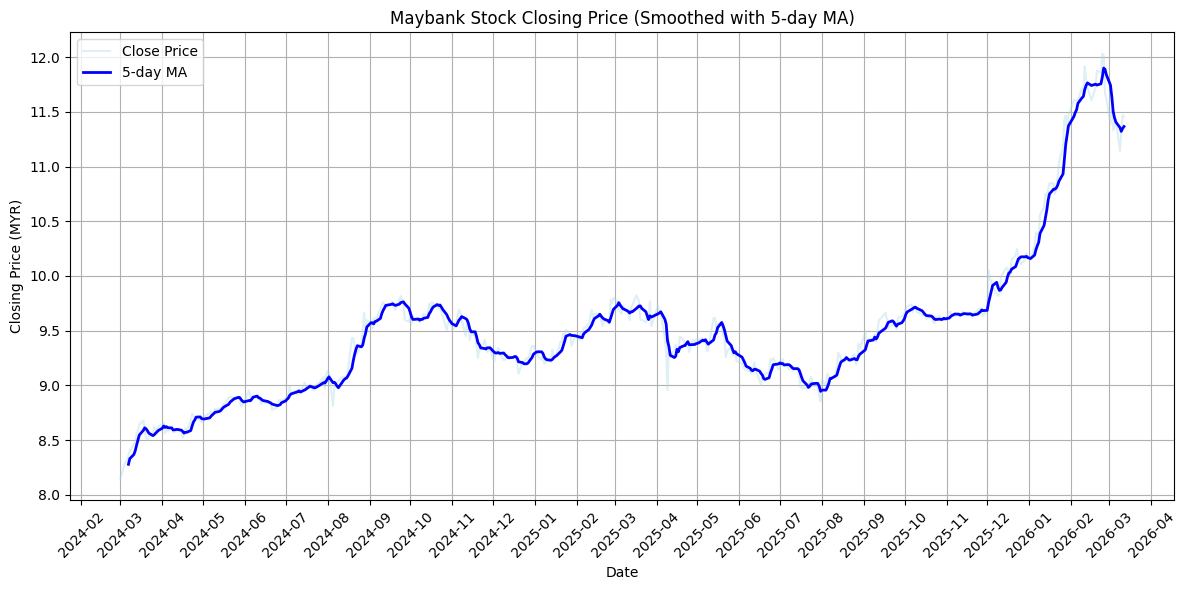

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 读取数据
df = pd.read_csv("Source/Data/raw/stock/Maybank_Stocks_Data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# 确保 Close 列为数值型，如果无法转则变成 NaN
df["Close"] = pd.to_numeric(df["Close"], errors='coerce')

# 计算 5 天滚动平均
df["Close_MA5"] = df["Close"].rolling(window=5).mean()

plt.figure(figsize=(12, 6))

# 原始收盘价（淡蓝）
plt.plot(df["Date"], df["Close"], linestyle="-", color='lightblue', alpha=0.4, label="Close Price")

# 滚动平均（深蓝）
plt.plot(df["Date"], df["Close_MA5"], linestyle="-", color='blue', linewidth=2, label="5-day MA")

# 设置 X 轴日期格式
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.title("Maybank Stock Closing Price (Smoothed with 5-day MA)")
plt.xlabel("Date")
plt.ylabel("Closing Price (MYR)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Align Data
Merge the sentiment scores and stock closing price based on the same date

In [16]:
import pandas as pd
import os

STOCK_PATH = "Source/Data/raw/stock/Maybank_Stocks_Data.csv"
SENTIMENT_PATH = "Source/Data/processed/sentiment/gpt-5_avg_sentiment.csv"

OUTPUT_DIR = "Source/Data/processed/sentiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "gpt-5_And_Closing_Price.csv"
)

# Load Maybank_Stocks_Data.csv and gpt-5_avg_sentiment.csv
stocks = pd.read_csv(STOCK_PATH)
sentiment = pd.read_csv(SENTIMENT_PATH)

# Convert Date format
stocks["Date"] = pd.to_datetime(stocks["Date"])
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Keep only the date and closing price
stocks_close = stocks[["Date", "Close"]]

# Merge sentiment score and closing price
merged_df = pd.merge(sentiment, stocks_close, on="Date", how="left") # how="left" means left join

# Sort the date by descending order and resets the row index back to 0, 1, 2, … after sorting, and drops the old index
merged_df = merged_df.sort_values("Date", ascending=False).reset_index(drop=True)

# Fills any missing values (NaN) by copying the value from the previous row
merged_df["Close"] = merged_df["Close"].ffill()

# save to gpt-5_Sentiment_And_Closing_Price.csv
merged_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("Merge Complete! Result saved to:")
print(OUTPUT_PATH)

Merge Complete! Result saved to:
Source/Data/processed/sentiment/gpt-5_And_Closing_Price.csv


In [17]:
import pandas as pd
import os

STOCK_PATH = "Source/Data/raw/stock/Maybank_Stocks_Data.csv"
SENTIMENT_PATH = "Source/Data/processed/sentiment/gpt-5-mini_avg_sentiment.csv"

OUTPUT_DIR = "Source/Data/processed/sentiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "gpt-5-mini_And_Closing_Price.csv"
)

# Load Maybank_Stocks_Data.csv and gpt-5-mini_avg_sentiment.csv
stocks = pd.read_csv(STOCK_PATH)
sentiment = pd.read_csv(SENTIMENT_PATH)

# Convert Date format
stocks["Date"] = pd.to_datetime(stocks["Date"])
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Keep only the date and closing price
stocks_close = stocks[["Date", "Close"]]

# Merge sentiment score and closing price
merged_df = pd.merge(sentiment, stocks_close, on="Date", how="left")

# Sort the date by descending order and resets the row index back to 0, 1, 2, … after sorting, and drops the old index
merged_df = merged_df.sort_values("Date", ascending=False).reset_index(drop=True)

# Fills any missing values (NaN) by copying the value from the previous row
merged_df["Close"] = merged_df["Close"].ffill()

# save to gpt-5-mini_Sentiment_And_Closing_Price.csv
merged_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("Merge Complete! Result saved to:")
print(OUTPUT_PATH)

Merge Complete! Result saved to:
Source/Data/processed/sentiment/gpt-5-mini_And_Closing_Price.csv


In [18]:
import pandas as pd
import os

STOCK_PATH = "Source/Data/raw/stock/Maybank_Stocks_Data.csv"
SENTIMENT_PATH = "Source/Data/processed/sentiment/gpt-5-nano_avg_sentiment.csv"

OUTPUT_DIR = "Source/Data/processed/sentiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "gpt-5-nano_And_Closing_Price.csv"
)

# Load Maybank_Stocks_Data.csv and gpt-5-nano_avg_sentiment.csv
stocks = pd.read_csv(STOCK_PATH)
sentiment = pd.read_csv(SENTIMENT_PATH)

# Convert Date format
stocks["Date"] = pd.to_datetime(stocks["Date"])
sentiment["Date"] = pd.to_datetime(sentiment["Date"])

# Keep only the date and closing price
stocks_close = stocks[["Date", "Close"]]

# Merge sentiment score and closing price
merged_df = pd.merge(sentiment, stocks_close, on="Date", how="left")

# Sort the date by descending order and resets the row index back to 0, 1, 2, … after sorting, and drops the old index
merged_df = merged_df.sort_values("Date", ascending=False).reset_index(drop=True)

# Fills any missing values (NaN) by copying the value from the previous row
merged_df["Close"] = merged_df["Close"].ffill()

# save to gpt-5-nano_Sentiment_And_Closing_Price.csv
merged_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print("Merge Complete! Result saved to:")
print(OUTPUT_PATH)

Merge Complete! Result saved to:
Source/Data/processed/sentiment/gpt-5-nano_And_Closing_Price.csv
